# Website Fingerprinting - Traffic Classification

## Introduction

The goal of this project is to implement a **website fingerprinting system**, capable of identifying which website a user is visiting by analyzing only **encrypted HTTPS traffic**.

Since HTTPS encrypts payload data, traditional inspection methods fail. Therefore, we rely on **statistical traffic features** such as packet sizes, inter-arrival times, and flow characteristics to distinguish between different websites.

This task is a typical **traffic classification problem**, where each captured traffic trace must be assigned to a specific website class.

## Phase 1: Dataset Construction (Data Collection)

The dataset is built by visiting a set of popular news websites multiple times and capturing the corresponding network traffic.

For each website:
- The page is visited 10 times
- Network packets are captured and stored in `.pcap` files
- Each file represents one browsing session

To simplify processing:
- `.pcap` files are converted into `.csv` format
- Only relevant HTTPS traffic is retained (filtering unnecessary packets)

Each capture file is labeled using the website name, providing the **ground truth** for supervised learning.

This step is crucial, as the quality and diversity of the dataset directly affect the classification performance.

In [ ]:
!apt-get update -qq
!apt-get install -y tshark tcpdump curl

In [1]:
import os
import time
import subprocess
import csv

In [2]:
# List of 10 news websites to visit
WEBSITES = [
    "https://www.indiatimes.com",
    "https://www.washingtonpost.com",
    "https://www.ndtv.com",
    "https://www.cnbc.com",
    "https://www.timesofindia.com",
    "https://www.express.co.uk",
    "https://www.rt.com",
    "https://www.news18.com",
    "https://www.nypost.com",
    "https://www.abc.net.au"
]

VISITS_PER_SITE = 10
BASE_OUTPUT_DIR = "Captured_Data"
PCAP_DIR = os.path.join(BASE_OUTPUT_DIR, "pcaps")

# Create necessary directory
os.makedirs(PCAP_DIR, exist_ok=True)

In [3]:
def collect_traffic():
    """Collects network traffic for specified websites and logs metadata."""

    metadata_log = os.path.join(BASE_OUTPUT_DIR, "capture_log.csv")

    # Open the metadata log file and write headers
    with open(metadata_log, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(["Website", "Domain_Label", "Visit_Number", "Pcap_File"])

        for site in WEBSITES:
            # Extract domain for labeling for example "indiatimes.com" from "https://www.indiatimes.com"
            domain = site.split("//")[-1].replace("www.", "")

            print(f"Sniffing traffic for {domain}")

            for visit in range(1, VISITS_PER_SITE + 1):
                filename = f"{domain.replace('.', '_')}_v{visit}.pcap"
                pcap_path = os.path.join(PCAP_DIR, filename)

                # BPF filter to capture only TCP traffic on port 443 (HTTPS)
                bpf_filter = "tcp port 443"

                # Start tcpdump to capture traffic
                print(f"Capturing visit {visit}/{VISITS_PER_SITE}...")
                tcpdump_cmd = ["tcpdump", "-i", "any", "-w", pcap_path, bpf_filter]
                capture_process = subprocess.Popen(tcpdump_cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

                # Wait a moment to ensure tcpdump is ready before making the web request
                time.sleep(1.5)

                # Make the web request using curl (silent, follow redirects, with a timeout)
                curl_cmd = ["curl", "-s", "-S", "-L", "--max-time", "20", site]
                subprocess.run(curl_cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

                # Wait a few seconds to ensure all traffic is captured, then stop tcpdump
                time.sleep(4)
                capture_process.terminate()
                capture_process.wait()

                # Log metadata for this capture
                writer.writerow([site, domain, visit, pcap_path])

    print(f"All captures complete! PCAPs saved in '{PCAP_DIR}'")
    print(f"Metadata saved to '{metadata_log}'")

In [ ]:
collect_traffic()

## Phase 2: Extracting the Biflow Features

From each traffic capture, we extract **bi-flow features**, considering both directions of communication:

### Uplink (client → server)
### Downlink (server → client)

The extracted features include:

- Number of packets
- Total transmitted bytes
- Packet size statistics:
  - Minimum
  - Maximum
  - Mean
  - Standard deviation
- Inter-Arrival Time (IAT) statistics:
  - Minimum
  - Maximum
  - Mean
  - Standard deviation

These features capture the **statistical behavior of encrypted traffic**, allowing us to differentiate between websites even without access to payload data.

Each capture is transformed into a **single feature vector**, which becomes one row in the dataset.

In [ ]:
!pip install scapy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 26.4 MB/s eta 0:00:00


In [7]:
import numpy as np
import pandas as pd
from pathlib import Path
from scapy.all import rdpcap, IP
from tqdm.notebook import tqdm

In [5]:
def get_stats(arr, prefix):
    """Helper to calculate min/max/mean/std safely."""

    if len(arr) == 0:
        return {f"{prefix}_min": 0, f"{prefix}_max": 0, f"{prefix}_mean": 0, f"{prefix}_std": 0}
    
    # Calculate and return statistics for the given array
    return {
        f"{prefix}_min": float(np.min(arr)),
        f"{prefix}_max": float(np.max(arr)),
        f"{prefix}_mean": float(np.mean(arr)),
        f"{prefix}_std": float(np.std(arr, ddof=0))
    }

In [6]:
# Directory containing the captured PCAP files
DATA_DIR = Path("Captured_Data/pcaps") # PCAP_DIR

def extract_features_with_scapy(pcap_path):
    """Extracts features from a single PCAP file using Scapy."""
    
    # Read packets from the PCAP file
    packets = rdpcap(str(pcap_path))
    

    if len(packets) == 0:
        return None

    # Identify the client IP (assuming it's the source of the first packet)
    client_ip = None
    for pkt in packets:
        if IP in pkt:
            client_ip = pkt[IP].src
            break
    
    # If we can't identify a client IP, skip this file
    if not client_ip:
        return None

    # Initialize lists to hold features
    up_sizes, down_sizes = [], []
    up_times, down_times = [], []

    # Iterate through packets to extract sizes and timestamps for up/down flows
    for pkt in packets:
        if IP in pkt:
            size = len(pkt)
            timestamp = float(pkt.time)

            # Classify as upload or download based on source/destination IP
            if pkt[IP].src == client_ip:
                up_sizes.append(size)
                up_times.append(timestamp)

            # Classify as download if the destination is the client IP
            elif pkt[IP].dst == client_ip:
                down_sizes.append(size)
                down_times.append(timestamp)

    # Calculate inter-arrival times (IAT) for up and down flows
    up_iat = np.diff(up_times) if len(up_times) > 1 else [0]
    down_iat = np.diff(down_times) if len(down_times) > 1 else [0]


    # Compile features into a dictionary
    features = {
        'pcap_filename': pcap_path.name,
        'up_packets': len(up_sizes),
        'down_packets': len(down_sizes),
        'up_bytes': sum(up_sizes),
        'down_bytes': sum(down_sizes)
    }

    # Add statistical features for sizes and IATs
    features.update(get_stats(up_sizes, 'up_size'))
    features.update(get_stats(down_sizes, 'down_size'))
    features.update(get_stats(up_iat, 'up_iat'))
    features.update(get_stats(down_iat, 'down_iat'))

    # Extract label from filename for example "indiatimes_v1.pcap" -> "indiatimes")
    features['label'] = pcap_path.stem.split('_v')[0]

    return features

In [8]:
# Process all PCAP files found in the directory
pcap_files = list(DATA_DIR.rglob("*.pcap"))

# Iterate through each PCAP file, extract features, and compile into a list
feature_list = []
for i, pcap in tqdm(enumerate(pcap_files, 1), total=len(pcap_files)):
    feats = extract_features_with_scapy(pcap)
    if feats:
        feature_list.append(feats)

# Convert the list of feature dictionaries into a DataFrame and save as CSV
dataset_df = pd.DataFrame(feature_list)
output_csv = DATA_DIR.parent / "ML_Dataset_Train.csv"
dataset_df.to_csv(output_csv, index=False)


  0%|          | 0/100 [00:00<?, ?it/s]

## Phase 3 

### Dataset Preparation

After feature extraction, all samples are combined into a single dataset.

Each row corresponds to:
- One traffic capture
- A set of extracted features
- The associated label (website name)

The dataset is then split into:
- **Training set (70%)**
- **Test set (30%)**

This split allows us to train the model on known data and evaluate its ability to generalize to unseen traffic.

### Classification Model: k-Nearest Neighbors (k-NN)

We use the **k-Nearest Neighbors (k-NN)** algorithm for classification.

#### How it works:
- For each test sample, the distance to all training samples is computed
- The **k closest samples** are selected
- The most frequent label among them is assigned to the test sample

#### Key characteristics:
- Distance metric: Euclidean distance
- Simple and non-parametric
- No training phase (lazy learning)

We evaluate performance for different values of **k (1 to 10)** to understand how it affects accuracy.

### Performance Evaluation

To evaluate the model, we use:

#### 1. Accuracy
The fraction of correctly classified samples.

#### 2. Confusion Matrix
Shows how predictions are distributed across classes:
- Helps identify which websites are confused with others

#### 3. Accuracy vs K
We analyze how performance changes with different values of k:
- Small k → sensitive to noise
- Large k → smoother but may lose detail

This analysis helps us choose the optimal value of k.

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [16]:
# Load the dataset
dataset_path = Path("Captured_Data/ML_Dataset_Train.csv") # output_csv
df = pd.read_csv(dataset_path)

# Build the feature matrix (X) and target vector (y)
X = df.drop(columns=['pcap_filename', 'label'])
y = df['label']

# Split the dataset into training and testing sets 70/30 with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [17]:
# Scale the Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:

# Train and evaluate for K = 1 - 10
results = {}

print("--- k-NN Evaluation ---")
for k in range(1, 11):
    
    # Train the k-NN model with distance weighting
    model = KNeighborsClassifier(n_neighbors=k, weights='distance')
    model.fit(X_train_scaled, y_train)

    # Predict on the test set
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    results[k] = acc
    print(f"\tk={k}: {acc}")

# Show the best K and its accuracy
best_k = max(results, key=results.get)
best_accuracy = results[best_k]
print(f"Best K: {best_k} with accuracy {best_accuracy}")


--- k-NN Evaluation ---
	k=1: 0.8
	k=2: 0.8
	k=3: 0.9
	k=4: 0.8333333333333334
	k=5: 0.8666666666666667
	k=6: 0.8333333333333334
	k=7: 0.8333333333333334
	k=8: 0.8333333333333334
	k=9: 0.8333333333333334
	k=10: 0.8333333333333334
Best K: 3 with accuracy 0.9


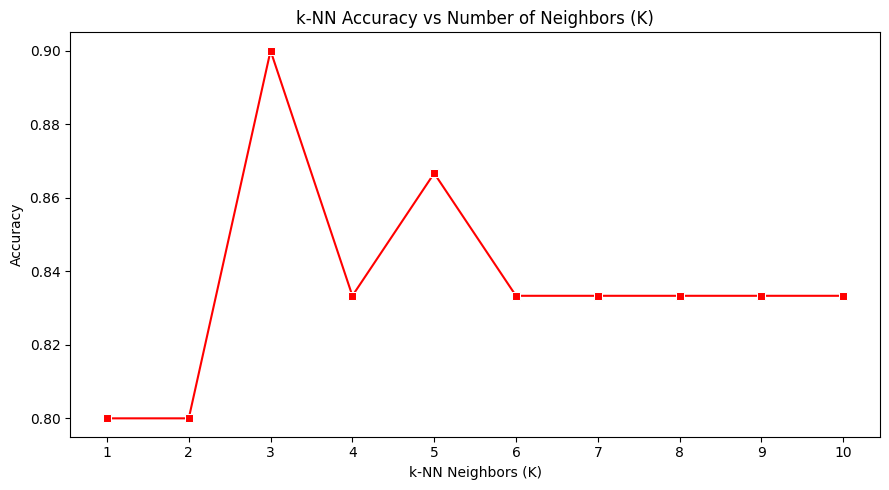

In [21]:
# 6. Plotting Accuracy vs K using Seaborn
plt.figure(figsize=(9, 5))
x = list(results.keys())
y = list(results.values())
sns.lineplot(x=x, y=y, marker="s", color="r")
plt.title("k-NN Accuracy vs Number of Neighbors (K)")
plt.xlabel("k-NN Neighbors (K)")
plt.ylabel("Accuracy")
plt.xticks(range(1, 11))
plt.tight_layout()
plt.show()

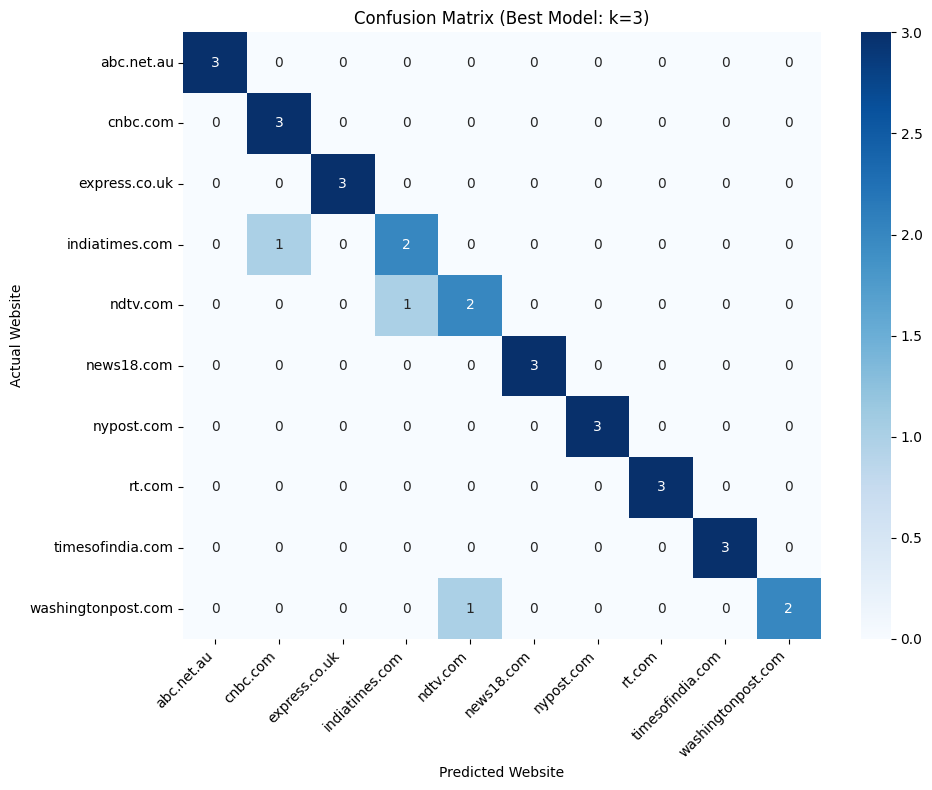

In [44]:
# Train the best model
best_model = KNeighborsClassifier(n_neighbors=best_k, weights='distance')
best_model.fit(X_train_scaled, y_train)
best_preds = best_model.predict(X_test_scaled)

classes = [cls.replace("_", ".") for cls in best_model.classes_]
# Confusion Matrix for the best model
cm = confusion_matrix(y_test, best_preds, labels=best_model.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes
)
plt.title(f"Confusion Matrix (Best Model: k={best_k})")
plt.xlabel("Predicted Website")
plt.ylabel("Actual Website")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Output Analysis & Results
The model achieves its peak performance at **$k=3$ with an accuracy of 90.0%**. 

Looking at the confusion matrix:
* The strong diagonal indicates that the model successfully learns the statistical footprint of most websites.
* There are minor misclassifications (e.g., `washingtonpost.com` being confused with `ndtv.com`, and `indiatimes.com` with `ndtv.com` and `cnbc.com`). This overlap is expected in network measurement, as websites with similar structural complexity, embedded media, or shared Content Delivery Networks (CDNs) can produce highly similar packet size and timing distributions.

## Phase 4: Temporal Evaluation (The New Test Set after 1 Day)

To evaluate robustness, a new dataset is collected at a later time.

The model is tested on this new data without retraining.

### Observations:
- Performance typically decreases compared to the original test set
- This is due to:
  - Network variability
  - Dynamic content changes
  - CDN and caching effects

This demonstrates that traffic patterns are **not perfectly stable over time**, making website fingerprinting a challenging problem.

In [ ]:
# Setup directory for the temporal test
TEST_DIR = Path("Captured_Data_Temporal_1D")
TEST_PCAP_DIR = TEST_DIR / "pcaps"
# Make sure the directory exists
TEST_PCAP_DIR.mkdir(parents=True, exist_ok=True)

# Number of visits per website for the new temporal test set
VISITS_NEW_TEST = 3

In [ ]:
def generate_temporal_dataset():
    """Captures new traffic and extracts features on the fly."""
    test_features_list = []
    print("Temporal Data Collection 1D")

    # Iterate through each website and perform multiple visits to capture new traffic
    for site in WEBSITES:
        domain = site.split("//")[-1].replace("www.", "")
        print(f"Sampling {domain}:")

        for visit in range(1, VISITS_NEW_TEST + 1):
            # Create a unique PCAP filename for this visit
            pcap_name = TEST_PCAP_DIR / f"{domain.replace('.', '_')}_temporal_v{visit}.pcap"

            print(f"Capturing visit {visit}/{VISITS_NEW_TEST}...")

            # Capture Traffic 
            tcpdump_cmd = ["tcpdump", "-i", "any", "-w", str(pcap_name), "tcp port 443"]
            proc = subprocess.Popen(tcpdump_cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

            time.sleep(1.5)

            # Make the web request using curl (silent, follow redirects, with a timeout)
            subprocess.run(["curl", "-s", "-S", "-L", "--max-time", "15", site], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
            time.sleep(3)
            proc.terminate()
            proc.wait()

            # Extract features immediately after capture
            feats = extract_features_with_scapy(pcap_name)

            # Manually assign the ground truth label based on the domain
            feats['label'] = domain.replace('.', '_')
            test_features_list.append(feats)

    return pd.DataFrame(test_features_list)

In [ ]:
temporal_df = generate_temporal_dataset()
temporal_csv_path = TEST_DIR / "temporal_test_features.csv"
temporal_df.to_csv(temporal_csv_path, index=False)

#### Evaluation

In [38]:
temporal_df = pd.read_csv("Captured_Data_Temporal_1D/temporal_test_features.csv") # temporal_csv_path

# Prepare the fresh data for evaluation using the same features and scaling as the training data
X_temporal = temporal_df.drop(columns=['pcap_filename', 'label'])
y_true_temporal = temporal_df['label']

# Scale the temporal features using the same scaler fitted on the training data
X_temporal_scaled = scaler.transform(X_temporal)

# Predict using the best model trained on the original dataset
y_pred_temporal = best_model.predict(X_temporal_scaled)

# Evaluate and visualize the results for the temporal test set
temporal_accuracy = accuracy_score(y_true_temporal, y_pred_temporal)
print(f"Temporal Evaluation Accuracy: {temporal_accuracy:.4f}")

Temporal Evaluation Accuracy: 0.1667


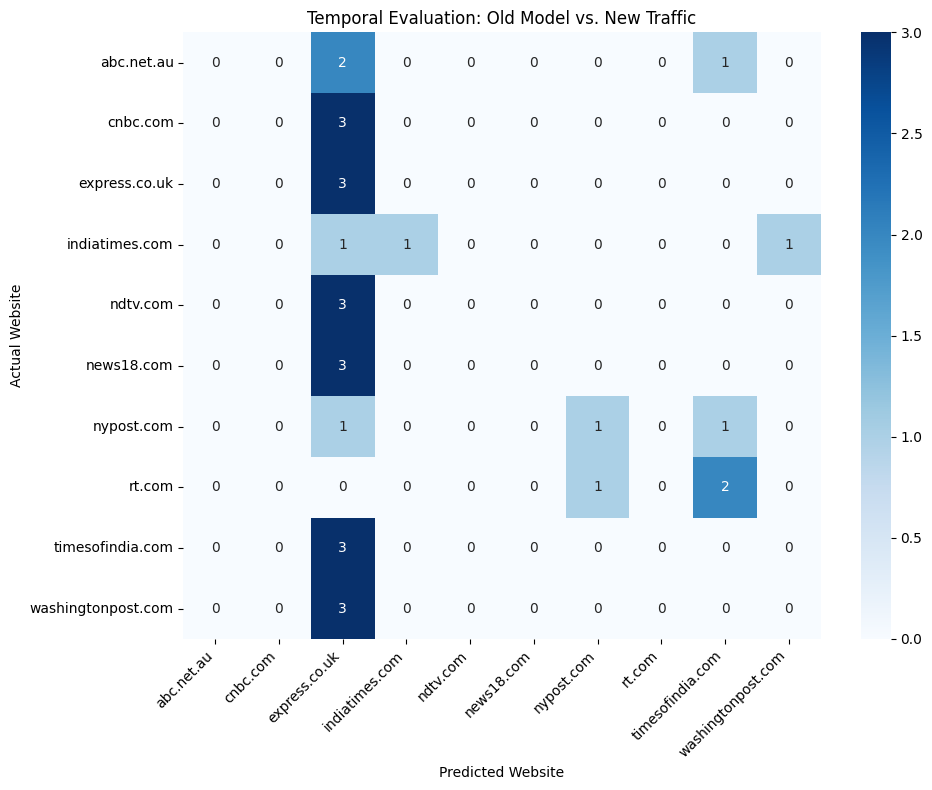

In [43]:
# Confusion Matrix for the temporal test set
classes = [cls.replace("_", ".") for cls in best_model.classes_]

cm_temporal = confusion_matrix(y_true_temporal, y_pred_temporal, labels=best_model.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_temporal,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes
)
plt.title(f"Temporal Evaluation: Old Model vs. New Traffic")
plt.xlabel("Predicted Website")
plt.ylabel("Actual Website")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Output Analysis & Results
The performance suffers a catastrophic drop, plummeting from **90.0% to 16.67%** accuracy. 

The confusion matrix shows complete misalignment. This severe degradation is a classic example of **concept drift** in network traffic classification. Modern news websites are highly dynamic; within 24 hours, the articles, images, and especially the dynamically injected third-party advertisements change entirely. Consequently, the biflow features (like total bytes or mean packet size) captured on day one no longer represent the website's footprint on day two.

## Phase 5 - Advanced Feature: Cumulative Trace Representation

In this approach, instead of statistical features, we use the **packet size sequence**:

- Incoming packets → positive values
- Outgoing packets → negative values

We compute a cumulative sum:

C(1) = p₁  
C(2) = p₁ + p₂  
C(3) = p₁ + p₂ + p₃  

Then:
- The curve is sampled at **M = 20 equidistant points**
- This produces a fixed-length feature vector

This method captures the **temporal structure of traffic**, which may improve classification accuracy.

In [45]:
from scapy.all import rdpcap, IP, TCP
from scipy.interpolate import interp1d

DATA_DIR = Path("Captured_Data")

# Number of equidistant points to sample from the cumulative trace
M_POINTS = 20

In [ ]:
def extract_trace_features(pcap_path):
    """Generates a cumulative packet trace and samples M equidistant points."""

    # Read packets from the PCAP file
    packets = rdpcap(str(pcap_path))
    
    # Dynamically locate the client IP (assuming it's the source of the first IP packet)
    client_ip = None
    for pkt in packets:
        if IP in pkt:
            client_ip = pkt[IP].src
            break

    signed_sizes = []

    for pkt in packets:
        if IP in pkt and TCP in pkt:
            if len(pkt[TCP].payload) == 0:
                continue

            size = len(pkt)
            # Classify as upload (negative) or download (positive) based on source/destination IP
            if pkt[IP].src == client_ip:
                signed_sizes.append(-size) # Uploads are negative to create a signed trace

            # Classify as download if the destination is the client IP
            elif pkt[IP].dst == client_ip:
                signed_sizes.append(size) # Downloads are positive

    # Generate the cumulative trace from the signed packet sizes
    cumulative_trace = np.cumsum(signed_sizes)

    # Sample M equidistant points from the cumulative trace using linear interpolation
    if len(cumulative_trace) > 1:
        # Create an original x-axis based on the length of the cumulative trace and a new x-axis for M points
        x_original = np.linspace(0, 1, num=len(cumulative_trace))
        x_sampled = np.linspace(0, 1, num=M_POINTS)

        # Use linear interpolation to sample the cumulative trace at M equidistant points 
        trace_function = interp1d(x_original, cumulative_trace, kind='linear')
        sampled_trace = trace_function(x_sampled)

    # If the cumulative trace has only one point, replicate it M times; if empty, use zeros
    else:
        val = cumulative_trace[0] if len(cumulative_trace) == 1 else 0
        sampled_trace = np.full(M_POINTS, val)

    # Compile features into a dictionary, including the sampled trace points and metadata
    features = {
        'pcap_filename': pcap_path.name,
        'label': pcap_path.stem.split('_v')[0],
        'total_trace_packets': len(signed_sizes)
    }

    # Each point is added as a separate feature named
    for i in range(M_POINTS):
        features[f'trace_pt_{i+1}'] = float(sampled_trace[i])

    return features


In [47]:
pcap_files = list(DATA_DIR.rglob("*.pcap"))
trace_list = [extract_trace_features(pcap) for pcap in pcap_files]
trace_list = [f for f in trace_list if f is not None]

trace_df = pd.DataFrame(trace_list)
trace_csv_path = DATA_DIR / "cumulative_trace_dataset.csv"
trace_df.to_csv(trace_csv_path, index=False)

In [ ]:
trace_df = pd.read_csv("Captured_Data/cumulative_trace_dataset.csv") # trace_csv_path
X_trace = trace_df.drop(columns=['pcap_filename', 'label', 'total_trace_packets'])
y_trace = trace_df['label']

# 2. Stratified Split (70/30)
X_train_tr, X_test_tr, y_train_tr, y_test_tr = train_test_split(X_trace, y_trace, test_size=0.30, random_state=77, stratify=y_trace)

# 3. Scale Features
scaler_tr = StandardScaler()
X_train_tr_scaled = scaler_tr.fit_transform(X_train_tr)
X_test_tr_scaled = scaler_tr.transform(X_test_tr)

In [49]:
trace_results = {}

print("Cumulative Trace k-NN Evaluation: ")
for k in range(1, 11):
    model_tr = KNeighborsClassifier(n_neighbors=k, weights='distance')
    model_tr.fit(X_train_tr_scaled, y_train_tr)
    trace_preds = model_tr.predict(X_test_tr_scaled)
    trace_results[k] = accuracy_score(y_test_tr, trace_preds)
    print(f"Accuracy for k={k}: {trace_results[k]:.4f}")

best_k_tr = max(trace_results, key=trace_results.get)
best_acc_tr = trace_results[best_k_tr]
print(f"Best Trace K: {best_k_tr} with accuracy {best_acc_tr:.4f}")

Cumulative Trace k-NN Evaluation: 
Accuracy for k=1: 0.9667
Accuracy for k=2: 0.9667
Accuracy for k=3: 0.9667
Accuracy for k=4: 0.9667
Accuracy for k=5: 0.9667
Accuracy for k=6: 0.9667
Accuracy for k=7: 0.9667
Accuracy for k=8: 0.9667
Accuracy for k=9: 0.9667
Accuracy for k=10: 0.9667
Best Trace K: 1 with accuracy 0.9667


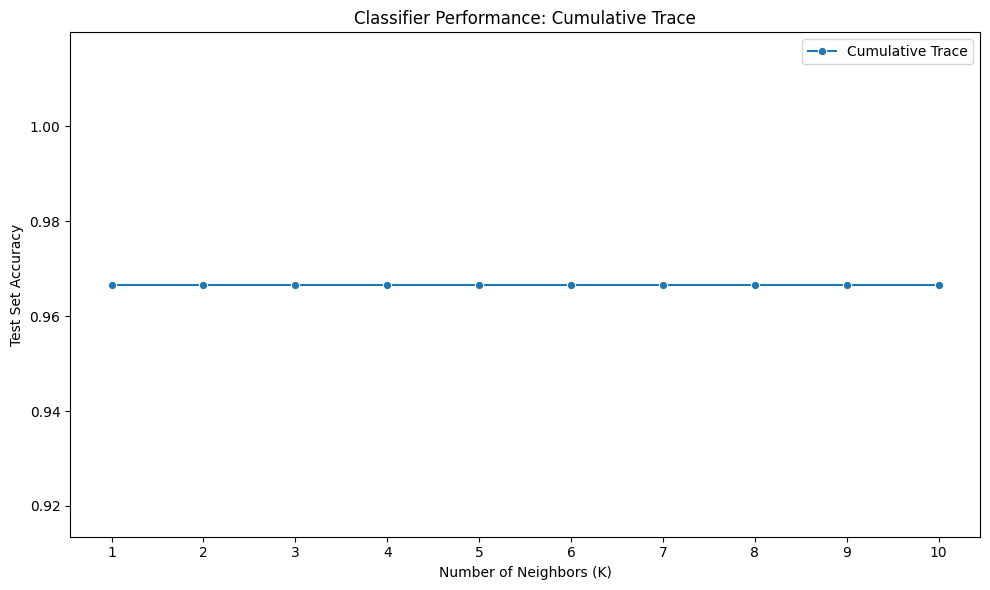

In [51]:
#
plt.figure(figsize=(10, 6))
sns.lineplot(x=list(trace_results.keys()), y=list(trace_results.values()), marker="o", label="Cumulative Trace")

plt.title("Classifier Performance: Cumulative Trace")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Test Set Accuracy")
plt.xticks(range(1, 11))
plt.legend()
plt.tight_layout()
plt.show()

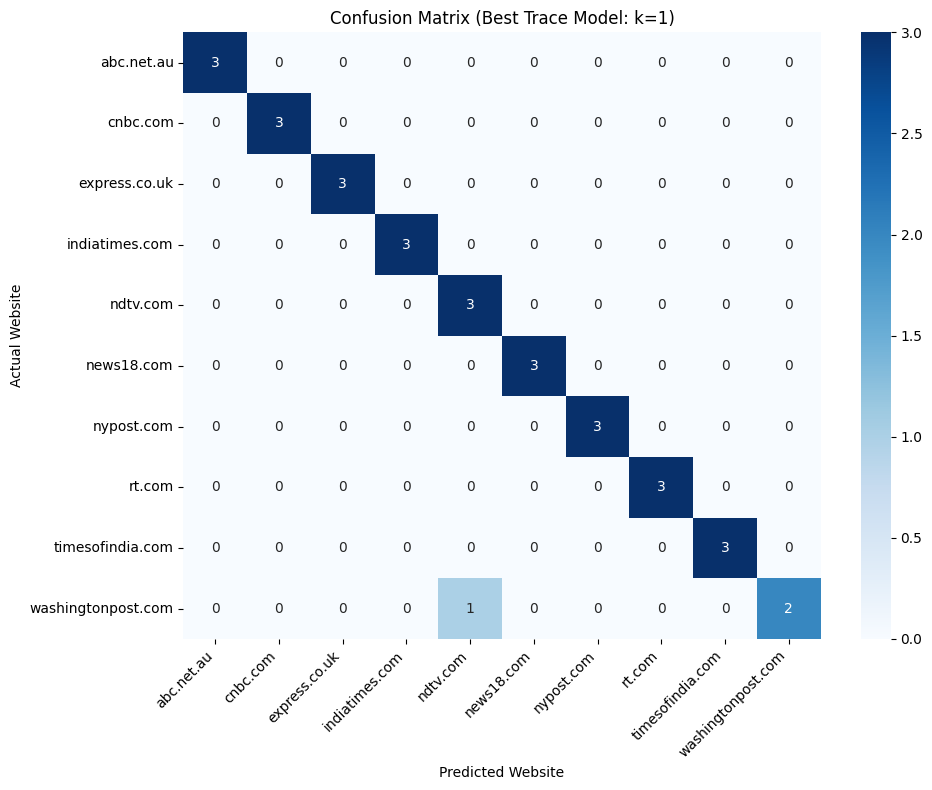

In [52]:
# Test Set Confusion Matrix for the best trace model
best_model_tr = KNeighborsClassifier(n_neighbors=best_k_tr, weights='distance')
best_model_tr.fit(X_train_tr_scaled, y_train_tr)
trace_preds_best = best_model_tr.predict(X_test_tr_scaled)

classes_tr = [cls.replace("_", ".") for cls in best_model_tr.classes_]
cm_tr = confusion_matrix(y_test_tr, trace_preds_best, labels=best_model_tr.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_tr,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes_tr,
    yticklabels=classes_tr
)
plt.title(f"Confusion Matrix (Best Trace Model: k={best_k_tr})")
plt.xlabel("Predicted Website")
plt.ylabel("Actual Website")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Test best trace model on the temporal test set
TEMPORAL_PCAP_DIR = Path("Captured_Data_Temporal_1D/pcaps")
temporal_pcap_files = list(TEMPORAL_PCAP_DIR.rglob("*.pcap"))
temporal_trace_list = [extract_trace_features(pcap) for pcap in temporal_pcap_files]
temporal_trace_list = [f for f in temporal_trace_list if f is not None]
temporal_trace_df = pd.DataFrame(temporal_trace_list)
temporal_trace_csv_path = TEMPORAL_PCAP_DIR.parent / "temporal_trace_test_features.csv"
temporal_trace_df.to_csv(temporal_trace_csv_path, index=False)

Temporal Trace Evaluation Accuracy: 0.1667


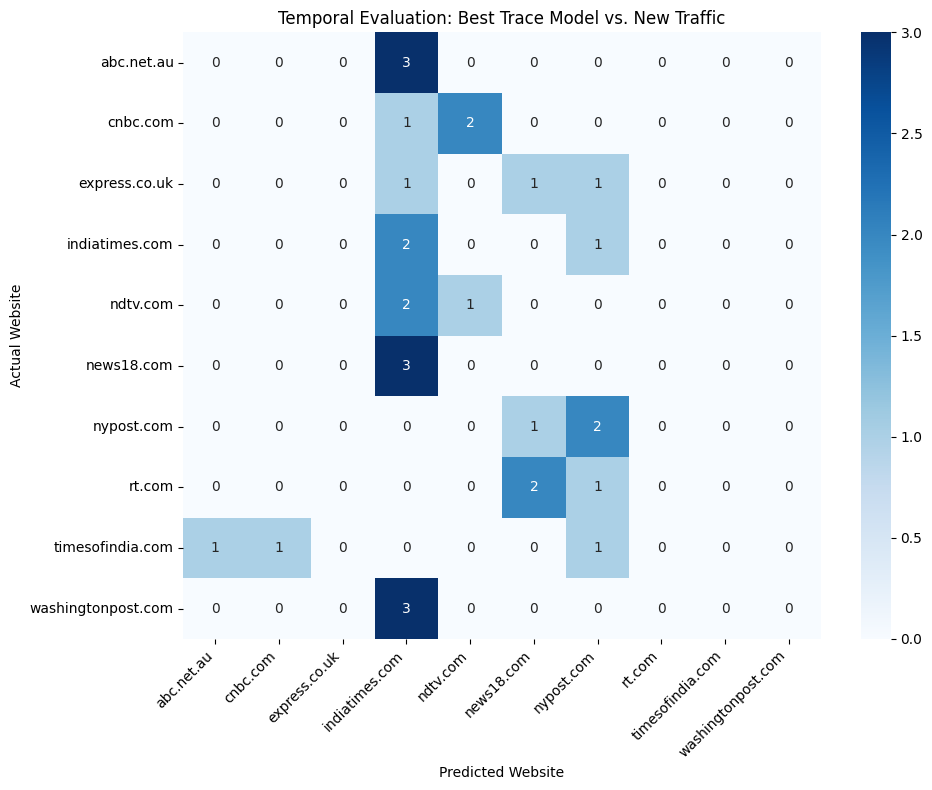

In [68]:
temporal_trace_df = pd.read_csv("Captured_Data_Temporal_1D/temporal_trace_test_features.csv") # temporal_trace_csv_path
X_temporal_tr = temporal_trace_df.drop(columns=['pcap_filename', 'label', 'total_trace_packets'])

y_true_temporal_tr = temporal_trace_df['label'].str.replace("_temporal", "", regex=False)

X_temporal_tr_scaled = scaler_tr.transform(X_temporal_tr)
y_pred_temporal_tr = best_model_tr.predict(X_temporal_tr_scaled)
temporal_acc_tr = accuracy_score(y_true_temporal_tr, y_pred_temporal_tr)
print(f"Temporal Trace Evaluation Accuracy: {temporal_acc_tr:.4f}")

# Confusion Matrix for the temporal trace evaluation
classes_temporal_tr = [cls.replace("_", ".") for cls in best_model_tr.classes_]
cm_temporal_tr = confusion_matrix(y_true_temporal_tr, y_pred_temporal_tr, labels=best_model_tr.classes_)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_temporal_tr,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes_temporal_tr,
    yticklabels=classes_temporal_tr
)
plt.title(f"Temporal Evaluation: Best Trace Model vs. New Traffic")
plt.xlabel("Predicted Website")
plt.ylabel("Actual Website")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Output Analysis:

**1. Performance on the Standard Test Set**
* **High Accuracy:** The k-NN classifier utilizing the Cumulative Trace features achieved a remarkable accuracy of **96.67%**. Interestingly, this high accuracy remained perfectly stable across all tested values of $K$ (from 1 to 10), with the model selecting $k=1$ as the best parameter.
* **Static Confusion Matrix:** The confusion matrix generated for the standard test split shows a near-perfect diagonal. This proves that sampling $M=20$ equidistant points from the cumulative packet trace creates an incredibly strong and distinct fingerprint. By capturing the actual "shape" of the page load (the sequence and trajectory of data exchange) rather than just bulk statistics, the classifier can separate the websites almost flawlessly when analyzing data collected in the same time window.

**2. Temporal Evaluation (1 Day Later)**
* **Catastrophic Accuracy Drop:** When the highly accurate Trace Model ($k=1$) was evaluated against the fresh temporal dataset captured just one day later, the accuracy plummeted to **16.67%**.
* **Temporal Confusion Matrix:** The heatmap for the temporal evaluation shows a scattered, noisy distribution with no clear diagonal. The model completely failed to correctly associate the new traffic with the learned website profiles.

**3. Core Takeaway (Fragility to Concept Drift)**
While the Cumulative Trace is vastly superior to basic statistical features for a static dataset, it is completely shattered by **concept drift**. The trace methodology relies on the exact sequence and cumulative size of the resources being loaded. Because the targets are dynamic news websites (like `cnn.com` or `ndtv.com`), their content changes rapidly. 

Within 24 hours, new front-page images are uploaded, different articles are featured, and background advertisement networks serve entirely different media. This completely alters the sequence of packets and the shape of the cumulative trace curve. Therefore, a trace fingerprint learned on Tuesday is practically useless for identifying that same news website on Wednesday.

## Final Comparison: Biflow Features vs. Cumulative Trace

To conclude our website fingerprinting analysis, we must compare the efficacy of the two feature sets we implemented: the statistical Biflow Features and the Cumulative Trace Features.

### 1. Performance on the Standard Dataset
* **Biflow Features:** Achieved an optimal accuracy of **90.00%** ($k=3$).
* **Cumulative Trace:** Achieved an optimal accuracy of **96.67%** ($k=1$).
* **Analysis:** The Cumulative Trace significantly outperformed the basic statistical features. By capturing the ordered sequence and trajectory of data exchange (the "shape" of the loading process) rather than just aggregated bulk statistics, the trace methodology creates a much more distinctive and reliable fingerprint for static classification.

### 2. Resilience to Temporal Changes (1 Day Later)
* **Biflow Features:** Accuracy dropped to **16.67%**.
* **Cumulative Trace:** Accuracy similarly dropped to **16.67%**.
* **Analysis:** Neither approach proved resilient to the passage of time. Because news websites frequently rotate their front-page content, update heavy multimedia, and cycle through dynamic advertisement networks, the structural loading shape (Cumulative Trace) and the overall volume (Biflow) fundamentally change day-to-day. 

**Conclusion:**
While the Cumulative Trace proposed by Panchenko et al. provides a superior fingerprint for a specific snapshot in time, both methods highlight a critical limitation in website fingerprinting: models must be continuously retrained to adapt to the rapidly shifting nature of modern, dynamic web content.